In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

In [16]:
VARIABLE = "edv" # temp or heat_index or edv

START_DATE = date(2018, 1, 1)
REGION = 5

INPUT_FILE = f"../data/{VARIABLE}/{VARIABLE}_stl.csv"
OUTPUT_FILE = f"../plots/stl/{VARIABLE}_stl.png"

df = pd.read_csv(INPUT_FILE, index_col = 0)
df

,seasonal,trend,remainder
1,-48.556446,54.351379,2.205067
2,-48.907744,54.345991,2.561753
3,-46.470276,54.340603,-7.870327
4,-44.992464,54.335216,-3.342752
5,-44.014652,54.329828,0.684824
...,...,...,...
2918,-47.321886,78.313586,-25.991701
2919,-46.968106,78.301325,-28.333219
2920,-48.114326,78.289063,-18.174738
2921,-48.556446,78.276802,-24.720356


In [17]:
END_DATE = START_DATE + timedelta(days = len(df)-1)
x_tick_ts = []
x_tick_years = []
for year in range(START_DATE.year, END_DATE.year+2):
    days_since = (date(year, 1, 1) - START_DATE).days + 1
    x_tick_ts.append(days_since)
    x_tick_years.append(year)

if VARIABLE == "edv":
    suptitle = "EDV"
elif VARIABLE == "temp":
    suptitle = "Temperature"
elif VARIABLE == "heat_index":
    suptitle = "Heat Index"

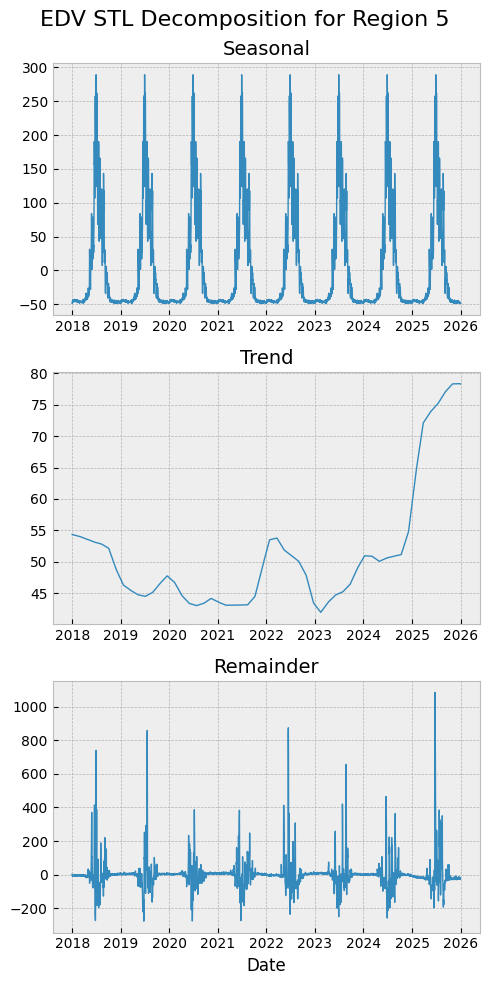

In [18]:
plt.style.use('bmh')
fig, axs = plt.subplots(3, 1, figsize = (5, 10))
for i, col in enumerate(df.columns):
    ax = axs[i]
    ax.plot(df[col], lw = 1)
    ax.set_title(col.capitalize(), fontsize = 14)
    ax.set_xticks(x_tick_ts, x_tick_years)

axs[2].set_xlabel("Date")

plt.suptitle(f"{suptitle} STL Decomposition for Region {REGION}", fontsize = 16)
plt.tight_layout()

fig.savefig(OUTPUT_FILE, dpi = 300)